## Model Building
### Approach
- Handle class imbalance using SMOTE
- Build Logistic Regression as baseline
- Evaluate using ROC-AUC (industry standard for healthcare ML)

### Imports

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from imblearn.over_sampling import SMOTE

import warnings

warnings.filterwarnings("ignore")

### Load Data

In [23]:
df = pd.read_csv("diabetic_ml_ready.csv")

X = df.drop(columns=["high_risk"])
y = df["high_risk"]

print("Features shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print(f"\nPositive class: {y.mean()*100:.1f}%")

Features shape: (101766, 66)
Target distribution:
high_risk
0    90409
1    11357
Name: count, dtype: int64

Positive class: 11.2%


###  Train/Test Split BEFORE SMOTE

In [24]:
# CRITICAL: Split BEFORE applying SMOTE
# SMOTE should only be applied on training data
# If SMOTE is applied before splitting, test data gets contaminated

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())

Training set: (81412, 66)
Test set: (20354, 66)

Training target distribution:
high_risk
0    72326
1     9086
Name: count, dtype: int64


### Apply SMOTE on training data only

In [25]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape, "| Positive:", y_train.sum())
print("After SMOTE :", X_train_smote.shape, "| Positive:", y_train_smote.sum())
print("\nAfter SMOTE target distribution:")
print(pd.Series(y_train_smote).value_counts())
print("Now perfectly balanced!")

Before SMOTE: (81412, 66) | Positive: 9086
After SMOTE : (144652, 66) | Positive: 72326

After SMOTE target distribution:
high_risk
0    72326
1    72326
Name: count, dtype: int64
Now perfectly balanced!


## Model 1: Logistic Regression

### Train Logistic Regression

In [26]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_smote, y_train_smote)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression trained!")

Logistic Regression trained!


### Evaluate

In [27]:
print("=" * 45)
print("     LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr))

     LOGISTIC REGRESSION RESULTS
Accuracy  : 0.7679
Precision : 0.1381
Recall    : 0.2061
F1 Score  : 0.1654
ROC-AUC   : 0.5452

              precision    recall  f1-score   support

           0       0.89      0.84      0.87     18083
           1       0.14      0.21      0.17      2271

    accuracy                           0.77     20354
   macro avg       0.52      0.52      0.52     20354
weighted avg       0.81      0.77      0.79     20354



### Confusion Matrix

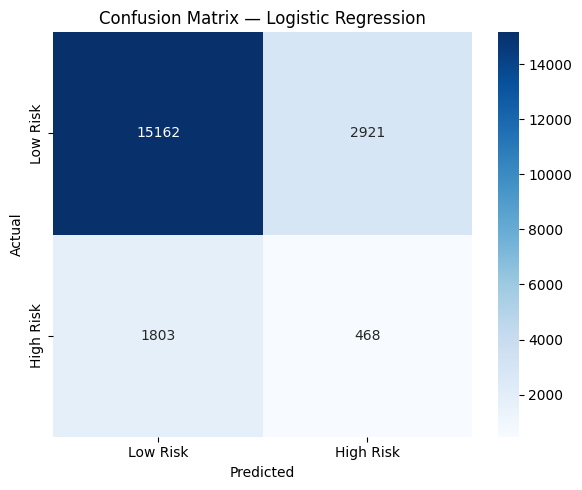


True Negatives  (correctly said Low Risk) : 15,162
False Positives (wrongly flagged High Risk): 2,921
False Negatives (missed High Risk patients): 1,803
True Positives  (correctly caught High Risk): 468

In healthcare, False Negatives are most costly!
We missed 1,803 high-risk patients who were not flagged.


In [28]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"],
)
plt.title("Confusion Matrix — Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("images/confusion_matrix_lr.png")
plt.show()

# Explain what the numbers mean
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly said Low Risk) : {tn:,}")
print(f"False Positives (wrongly flagged High Risk): {fp:,}")
print(f"False Negatives (missed High Risk patients): {fn:,}")
print(f"True Positives  (correctly caught High Risk): {tp:,}")
print(f"\nIn healthcare, False Negatives are most costly!")
print(f"We missed {fn:,} high-risk patients who were not flagged.")

###  ROC Curve

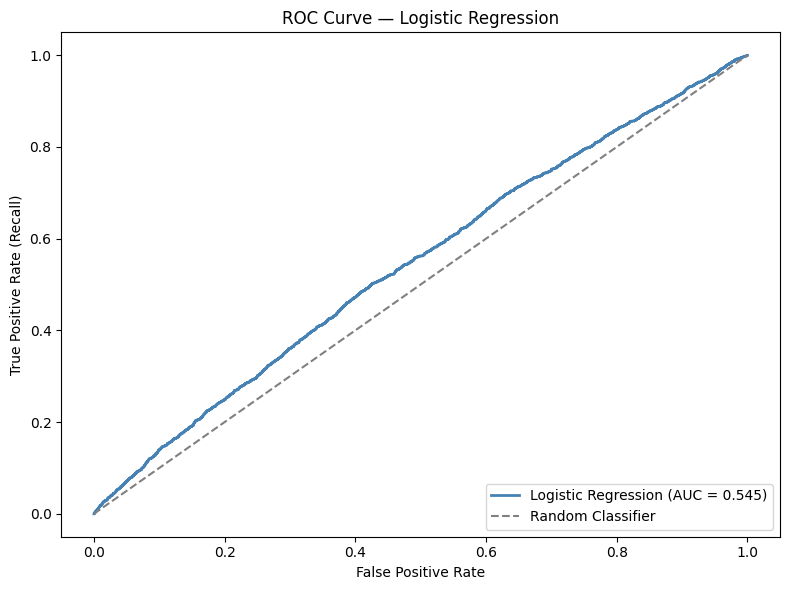

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
auc = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr, color="steelblue", lw=2, label=f"Logistic Regression (AUC = {auc:.3f})"
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/roc_curve_lr.png")
plt.show()

## Day 3 Summary — Logistic Regression Baseline

### Key Decisions
- Applied SMOTE AFTER train/test split (critical — prevents data leakage)
- SMOTE balanced training set from 8:1 → 1:1 ratio
- Using ROC-AUC as primary metric (better than accuracy for imbalanced data)

### Why ROC-AUC matters here
- With 88.8% negative class, a model predicting ALL negatives gets 88.8% accuracy
- ROC-AUC measures TRUE discriminative ability regardless of class balance
- AUC of 0.5 = random, AUC of 1.0 = perfect

### Healthcare Context
- False Negatives (missed high-risk patients) are most costly
- A hospital would rather over-flag (false positive) than miss a real case

### Results
- Logistic Regression ROC-AUC: 0.545 — barely above random
- This is expected — linear model struggles with 66 complex 
  clinical features and non-linear relationships
- Recall of 20.6% means we miss 79.4% of high-risk patients
- This establishes our baseline — tree-based models should 
  significantly improve ROC-AUC
- Next: Random Forest — expected ROC-AUC 0.65-0.75

## Model 2: Random Forest

### Train Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print("Random Forest trained!")

Random Forest trained!


### Evaluate

In [31]:
print("=" * 45)
print("        RANDOM FOREST RESULTS")
print("=" * 45)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf))

        RANDOM FOREST RESULTS
Accuracy  : 0.8419
Precision : 0.1500
Recall    : 0.0894
F1 Score  : 0.1120
ROC-AUC   : 0.5994

              precision    recall  f1-score   support

           0       0.89      0.94      0.91     18083
           1       0.15      0.09      0.11      2271

    accuracy                           0.84     20354
   macro avg       0.52      0.51      0.51     20354
weighted avg       0.81      0.84      0.82     20354



### Confusion Matrix

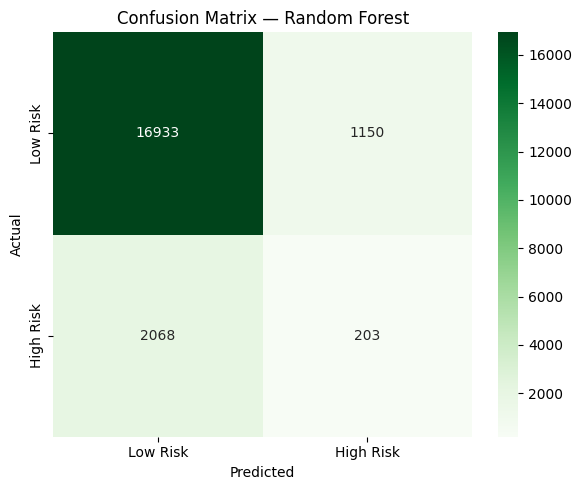


True Negatives  : 16,933
False Positives : 1,150
False Negatives : 2,068
True Positives  : 203

Improvement over LR:
Caught -265 more high-risk patients than Logistic Regression


In [32]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"],
)
plt.title("Confusion Matrix — Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("images/confusion_matrix_rf.png")
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"\nTrue Negatives  : {tn:,}")
print(f"False Positives : {fp:,}")
print(f"False Negatives : {fn:,}")
print(f"True Positives  : {tp:,}")
print(f"\nImprovement over LR:")
print(f"Caught {tp - 468:+,} more high-risk patients than Logistic Regression")

### ROC Curve comparison

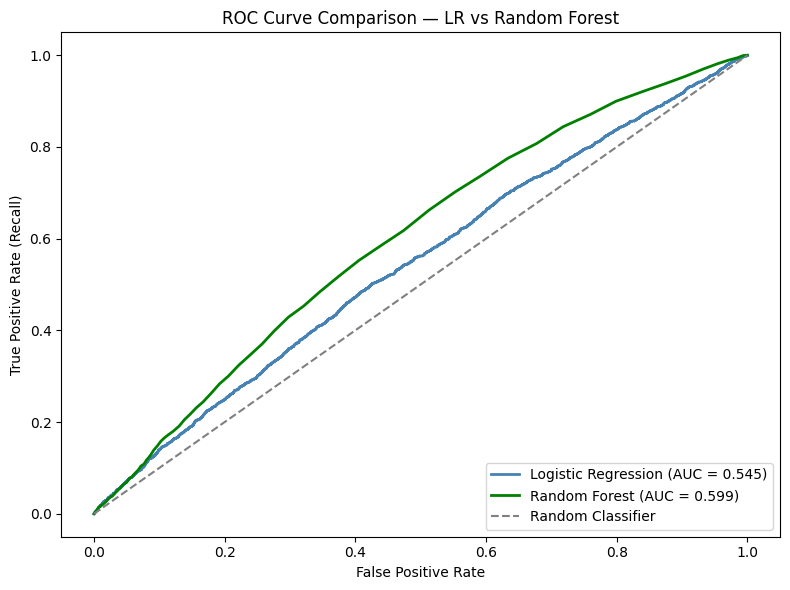

In [33]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    color="steelblue",
    lw=2,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})",
)
plt.plot(
    fpr_rf, tpr_rf, color="green", lw=2, label=f"Random Forest (AUC = {auc_rf:.3f})"
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison — LR vs Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/roc_curve_comparison.png")
plt.show()

### Feature Importance

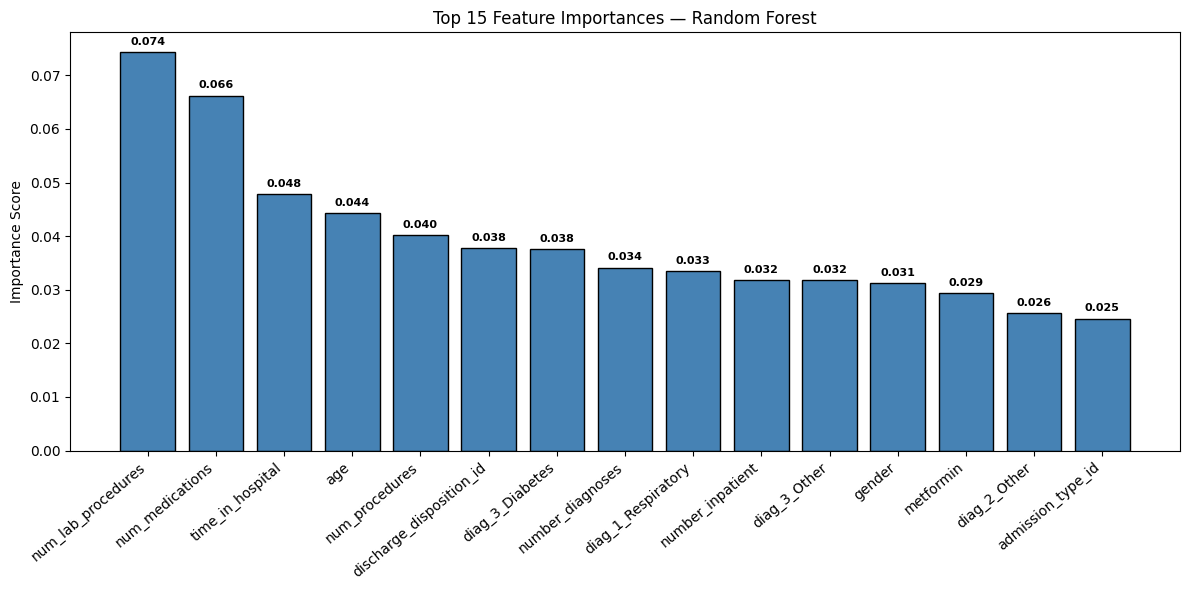


Top 5 most important features:
  num_lab_procedures: 0.0743
  num_medications: 0.0662
  time_in_hospital: 0.0478
  age: 0.0443
  num_procedures: 0.0401


In [34]:
feature_names = X.columns.tolist()
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # top 15 only

plt.figure(figsize=(12, 6))
bars = plt.bar(range(15), importances[indices], color="steelblue", edgecolor="black")

for bar, imp in zip(bars, importances[indices]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{imp:.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
    )

plt.xticks(range(15), [feature_names[i] for i in indices], rotation=40, ha="right")
plt.title("Top 15 Feature Importances — Random Forest")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.savefig("images/feature_importance_rf.png")
plt.show()

print("\nTop 5 most important features:")
for i in indices[:5]:
    print(f"  {feature_names[i]}: {importances[i]:.4f}")

## Day 4 Summary — Random Forest

### Results vs Logistic Regression
- ROC-AUC improved: 0.545 → 0.599
- Accuracy improved: 76.8% → 84.2%
- BUT Recall dropped: 20.6% → 8.9% — RF misses more high-risk patients
- Classic precision-recall tradeoff — RF is more conservative

### Top 5 Clinical Features (Feature Importance)
1. num_lab_procedures (0.074) — more tests = sicker patient
2. num_medications (0.066) — complex medication regime = higher risk
3. time_in_hospital (0.048) — longer stay = higher risk
4. age (0.044) — older patients readmit more
5. num_procedures (0.040) — more procedures = more complex case

### Key Insight
- In healthcare, Recall > Precision — missing a high-risk patient 
  is costlier than a false alarm

## Model 3: XGBoost

### Train XGBoost

In [35]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss",
    verbosity=0,
    scale_pos_weight=8,  # handles class imbalance directly
)
xgb.fit(
    X_train, y_train
)  # Note: using original X_train (no SMOTE needed — scale_pos_weight handles it)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
print("XGBoost trained!")

XGBoost trained!


### Evaluate

In [36]:
print("=" * 45)
print("          XGBOOST RESULTS")
print("=" * 45)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb))

          XGBOOST RESULTS
Accuracy  : 0.6817
Precision : 0.1790
Recall    : 0.5165
F1 Score  : 0.2658
ROC-AUC   : 0.6591

              precision    recall  f1-score   support

           0       0.92      0.70      0.80     18083
           1       0.18      0.52      0.27      2271

    accuracy                           0.68     20354
   macro avg       0.55      0.61      0.53     20354
weighted avg       0.84      0.68      0.74     20354



### Confusion Matrix

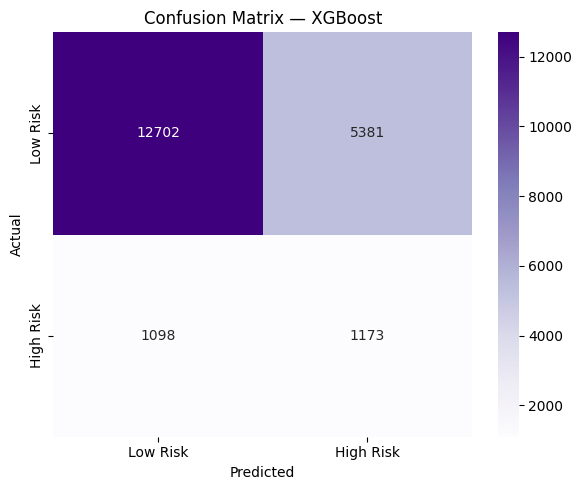


True Negatives  : 12,702
False Positives : 5,381
False Negatives : 1,098
True Positives  : 1,173


In [37]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Low Risk", "High Risk"],
    yticklabels=["Low Risk", "High Risk"],
)
plt.title("Confusion Matrix — XGBoost")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("images/confusion_matrix_xgb.png")
plt.show()

tn, fp, fn, tp = cm_xgb.ravel()
print(f"\nTrue Negatives  : {tn:,}")
print(f"False Positives : {fp:,}")
print(f"False Negatives : {fn:,}")
print(f"True Positives  : {tp:,}")

### ROC Curve — All 3 models

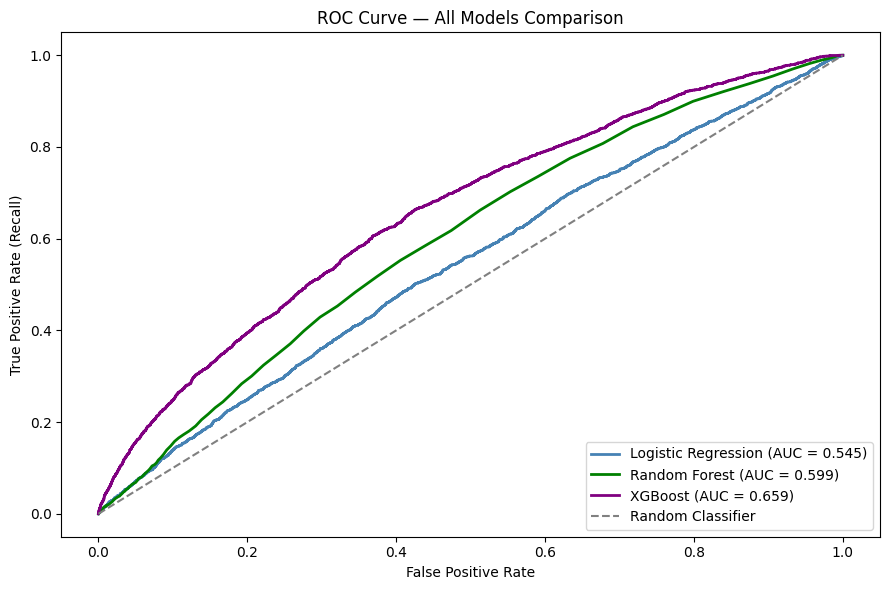

In [38]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(9, 6))
plt.plot(
    fpr,
    tpr,
    color="steelblue",
    lw=2,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})",
)
plt.plot(
    fpr_rf,
    tpr_rf,
    color="green",
    lw=2,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})",
)
plt.plot(
    fpr_xgb,
    tpr_xgb,
    color="purple",
    lw=2,
    label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})",
)
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — All Models Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("images/roc_curve_all_models.png")
plt.show()

### Feature Importance XGBoost

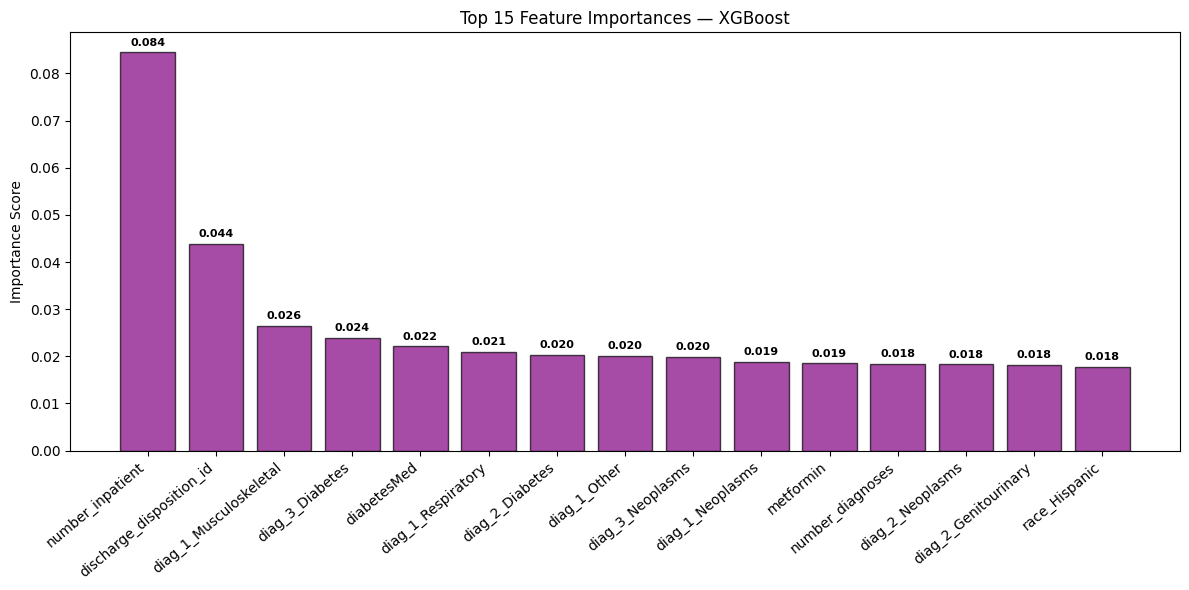


Top 5 most important features:
  number_inpatient: 0.0845
  discharge_disposition_id: 0.0439
  diag_1_Musculoskeletal: 0.0265
  diag_3_Diabetes: 0.0239
  diabetesMed: 0.0221


In [39]:
feature_names = X.columns.tolist()
importances_xgb = xgb.feature_importances_
indices_xgb = np.argsort(importances_xgb)[::-1][:15]

plt.figure(figsize=(12, 6))
bars = plt.bar(
    range(15),
    importances_xgb[indices_xgb],
    color="purple",
    edgecolor="black",
    alpha=0.7,
)

for bar, imp in zip(bars, importances_xgb[indices_xgb]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{imp:.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
    )

plt.xticks(range(15), [feature_names[i] for i in indices_xgb], rotation=40, ha="right")
plt.title("Top 15 Feature Importances — XGBoost")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.savefig("images/feature_importance_xgb.png")
plt.show()

print("\nTop 5 most important features:")
for i in indices_xgb[:5]:
    print(f"  {feature_names[i]}: {importances_xgb[i]:.4f}")

### Final comparison table

              FINAL MODEL COMPARISON
              Model  ROC-AUC  Accuracy   Recall  F1 Score
Logistic Regression 0.545219  0.767908 0.206077  0.165371
      Random Forest 0.599420  0.841898 0.089388  0.112031
            XGBoost 0.659132  0.681684 0.516513  0.265836

Best ROC-AUC: XGBoost
Best Recall : XGBoost


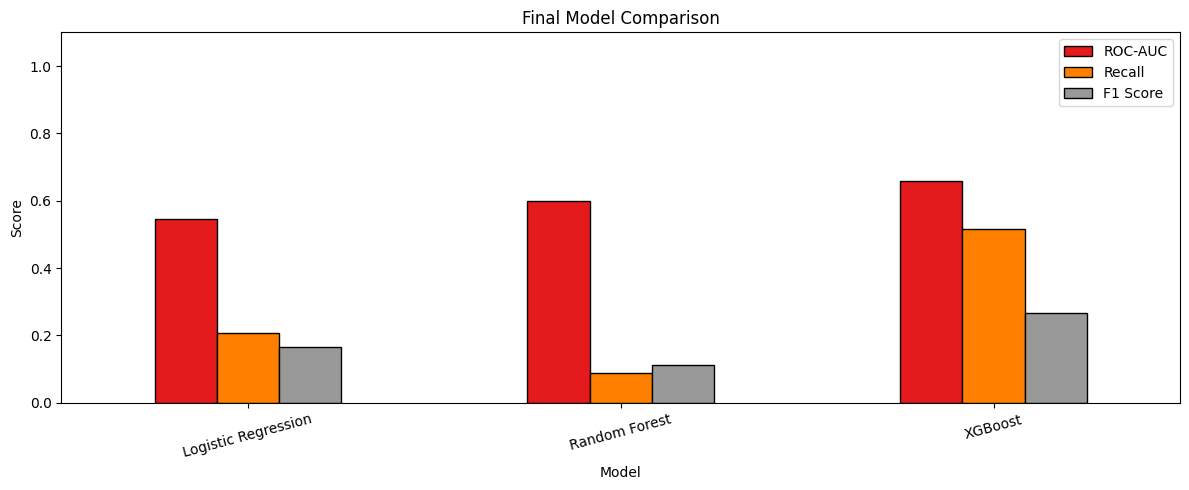

In [40]:
results = {
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
    ],
}

df_results = pd.DataFrame(results)
print("=" * 65)
print("              FINAL MODEL COMPARISON")
print("=" * 65)
print(df_results.to_string(index=False))
print()
print(f"Best ROC-AUC: {df_results.loc[df_results['ROC-AUC'].idxmax(), 'Model']}")
print(f"Best Recall : {df_results.loc[df_results['Recall'].idxmax(), 'Model']}")

# Bar chart
df_results.set_index("Model")[["ROC-AUC", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(12, 5), colormap="Set1", edgecolor="black"
)
plt.title("Final Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("images/final_model_comparison.png")
plt.show()

## Day 5 Summary — Final Model Comparison

### XGBoost Wins on All Key Metrics
- Best ROC-AUC: 0.659 (vs RF: 0.599, LR: 0.545)
- Best Recall: 51.7% — catches 1,173 high-risk patients 
  vs RF's 203 — 5.8x more high-risk patients caught!
- scale_pos_weight=8 handled imbalance better than SMOTE for XGBoost

### Top Clinical Predictors (XGBoost)
1. number_inpatient — prior hospitalization history is #1 signal
2. discharge_disposition_id — discharge destination matters
3. diag_3_Diabetes — diabetes as tertiary diagnosis
4. diabetesMed — medication regime complexity

### Final Recommendation
- Deploy XGBoost — best ROC-AUC AND best Recall
- In healthcare, catching more high-risk patients outweighs 
  having more false alarms